# Regresión lineal

#### Elección de variable: 

Vamos a tomar como la variable objetivo magnitude, porque es numérica, interpretable y tiene sentido predecirla a partir de otras características

#### Representar los datos:

Importamos la librería de Pandas para manipular los datos en formato de tabla, Numpy para operaciones matemáticas y Matplotlib para visualizar los datos antes de modelar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

def read_file(file_name):
    file = pd.read_csv(file_name)
    X = pd.DataFrame({'depth': file['depth'],'cdi': file['cdi'],'mmi': file['mmi'],'sig': file['sig']})
    y = pd.DataFrame({'magnitude': file['magnitude']})
    return X, y

In [3]:
X, y = read_file('earthquake_alert_balanced_dataset.csv')
print("10 primeros ejemplos del dataset: \n", X.head(10), "\n", y.head(10))

10 primeros ejemplos del dataset: 
    depth  cdi  mmi    sig
0   14.0  8.0  7.0    0.0
1   25.0  4.0  4.0  -33.0
2  579.0  3.0  3.0  -13.0
3   37.0  5.0  5.0   65.0
4  624.0  0.0  2.0  -98.0
5  660.0  4.0  3.0  -13.0
6  630.0  1.0  3.0  -57.0
7   20.0  7.0  6.0   29.0
8   20.0  8.0  7.0 -101.0
9   26.0  9.0  8.0    7.0 
    magnitude
0        7.0
1        6.9
2        7.0
3        7.3
4        6.6
5        7.0
6        6.8
7        6.7
8        6.8
9        7.6


#### Comprobar si hay valores nulos

Los algoritmos matemáticos como la regresión lineal fallan si encuentran valores vacíos (NaN). Verificamos los datos para asegurar que el entrenamiento no se rompa.

In [4]:
full_data= pd.read_csv('earthquake_alert_balanced_dataset.csv')
print("valores nulos por columna:")
print(full_data.isnull().sum())

valores nulos por columna:
magnitude    0
depth        0
cdi          0
mmi          0
sig          0
alert        0
dtype: int64


No hay valores nulos que puedan entorpecer el entrenamiento, asi que podemos proceder sin problema

#### Visualización de los datos

Haremos una gráfica de dispersión de cada una de las variables con magnitude para verificar visualmente si existe una relación lineal (una línea recta) entre las características (X) y el objetivo (y).

##### Magnitude y Depth

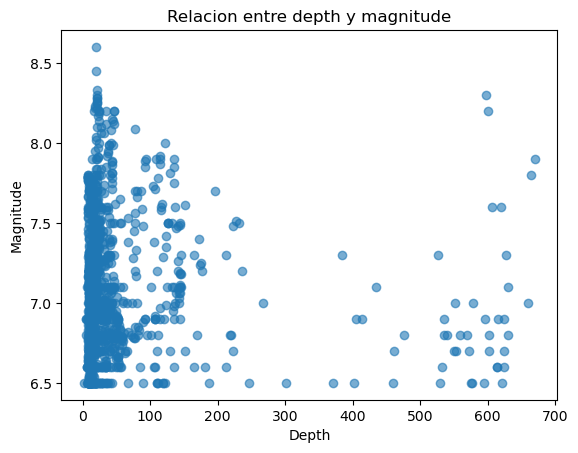

In [5]:
plt.scatter(X['depth'],y,alpha=0.6)
plt.xlabel('Depth')
plt.ylabel('Magnitude')
plt.title('Relacion entre depth y magnitude')
plt.show()

La relación aquí no es lineal. Podemos ver que la gran mayoría de terremotos se concentran en profundidades bajas. Hay una segunda agrupación más dispersa a profundidades mayores con menor magnitud

##### Magnitude y cdi

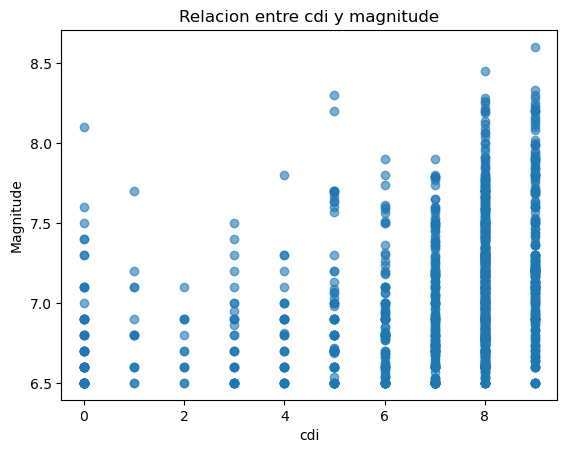

In [6]:
plt.scatter(X['cdi'],y,alpha=0.6)
plt.xlabel('cdi')
plt.ylabel('Magnitude')
plt.title('Relacion entre cdi y magnitude')
plt.show()

Muestra tendencia lineal positiva con la magnitud. A medida que aumentan los valores de cdi, aumenta la magnitud del terremoto.

##### Magnitude y mmi

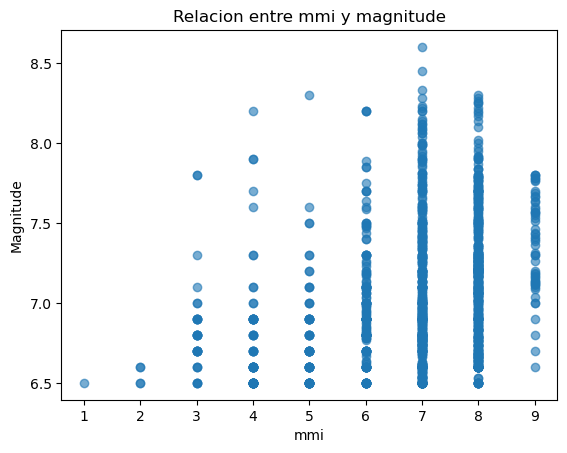

In [7]:
plt.scatter(X['mmi'],y,alpha=0.6)
plt.xlabel('mmi')
plt.ylabel('Magnitude')
plt.title('Relacion entre mmi y magnitude')
plt.show()

Muestra tendencia lineal positiva con la magnitud. A medida que aumentan los valores de cdi, aumenta la magnitud del terremoto.

##### Magnitude y sig

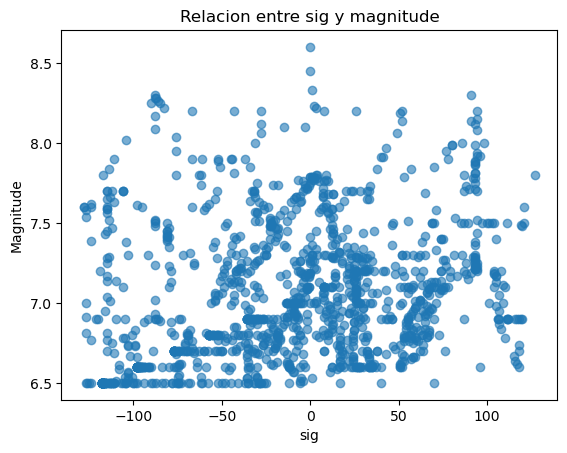

In [8]:
plt.scatter(X['sig'],y,alpha=0.6)
plt.xlabel('sig')
plt.ylabel('Magnitude')
plt.title('Relacion entre sig y magnitude')
plt.show()


No muestra relación lineal. Los puntos forman una nube aleatoria sin tendencia clara. Sugiere que sig no es un buen predictor para un modelo lineal.


#### Division de los datos en los conjuntos test y training

Procedemos a dividir los datos en un conjunto de training (80%) y un conjunto de test (20%). Es fundamental para evaluar el modelo, ya que si entrenamos y probamos con los mismos datos, el modelo podría memorizar las respuestas. Necesitamos datos nuevos, como los de test, para ver si el modelo funciona correctamente  de forma generalizada, después de haberlos entrenado con el conjunto de train.

Barajamos los datos para eliminar cualquier posibilidad de que los datos estuviesen ordenados.

In [9]:
# Barajamos los datos
data_shuffle= full_data.sample(frac=1,random_state=42)
#definimos el tamaño de la división
train_size=int(0.8*len(data_shuffle))
#dividimos los conjuntos
train_data=data_shuffle[:train_size]
test_data=data_shuffle[train_size:]

print(f"Datos de entrenamiento: {len(train_data)} filas")
print(f"Datos de prueba: {len(test_data)} filas")

#separamos x e y para ambos conjuntos
X_train= train_data[['depth', 'cdi', 'mmi', 'sig']]
y_train= pd.DataFrame(train_data['magnitude'])

X_test= test_data[['depth', 'cdi', 'mmi', 'sig']]
y_test= pd.DataFrame(test_data['magnitude'])

Datos de entrenamiento: 1040 filas
Datos de prueba: 260 filas


#### Normalizamos los datos con la desviacion estandar

Debemos generalizar los datos ya que las variables tienen escalas muy distintas entre sí. Si no normalizamos, el Descenso del Gradiente tardará mucho en converger o no lo hará, ya que los pasos hacia el mínimo serán desiguales. Al estandarizar, hacemos que sea más fácil de recorrer el conjunto de datos.

Definimos y utilizamos la funcion featureNormalize sobre nuestro conjunto train

In [10]:

# featureNormalize normaliza las características de X.

# featureNormalize(X) devuelve una versión normalizada de X donde
# el valor medio de cada característica es 0 y la desviación estándar
# es 1. Este suele ser un buen paso de preprocesamiento al
# trabajar con algoritmos de aprendizaje.

def featureNormalize(X):
    X_norm = X
    X_norm = (X - X.mean()) / (X.std())
    mu = X.mean()
    sigma = X.std()
    return X_norm, mu, sigma

In [11]:
X_train_norm, mu, sigma = featureNormalize(X_train)
# X = conjunto de datos normalizado
# mu = vector que contiene la media de cada atributo antes de la normalización
# sigma = vector que contiene la desviación estándar antes de la normalización

print(X_train_norm.head(10))
print("\nMU (training):\n ", mu, " \n\nSIGMA (training) :\n", sigma)

         depth       cdi       mmi       sig
478  -0.383074  0.895581  0.768928  0.159344
721  -0.383074  0.451633  0.768928  0.514960
312  -0.258832 -2.656009 -1.416004 -1.424767
660   0.610864  0.451633  0.768928  1.662632
823  -0.297060  0.451633  0.768928 -0.244766
115  -0.239718 -0.436265 -0.687693 -1.085314
901  -0.392631  0.895581  0.768928  0.579618
631  -0.344846  0.451633  0.040617  0.563453
1102 -0.144147  0.007684  0.040617  2.066742
101   0.066109 -0.436265 -1.416004  1.953591

MU (training):
  depth    50.082692
cdi       6.982692
mmi       6.944231
sig      -9.857692
dtype: float64  

SIGMA (training) :
 depth    104.634268
cdi        2.252512
mmi        1.373041
sig       61.864384
dtype: float64


Normalizamos X_test de forma manual usando la media y sigma de X_train

In [12]:
X_test_norm= (X_test-mu)/sigma
print(X_test_norm.head(10))

         depth       cdi       mmi       sig
476  -0.029462  0.451633  0.040617 -0.551890
157   0.171237 -1.768112 -0.687693 -1.731890
16   -0.163261  0.895581  0.768928  1.307015
546  -0.297060  0.451633  0.040617  0.013864
658  -0.268389  0.451633  0.768928  1.193864
1067  0.907134 -0.436265 -0.687693  1.048385
1019 -0.325732  0.451633  0.768928 -0.422574
1091 -0.306617  0.451633  0.040617 -0.390246
959  -0.354403  0.451633  0.768928  0.030028
1224 -0.134590  0.007684  0.040617  0.741262


#### Creamos la columna de unos

La ecuación de la recta es $y = \theta_0 + \theta_1 x_1 ...$

Para poder multiplicar matrices, necesitamos que el término independiente $\theta_0$ (la intersección) se multiplique por algo. Añadimos un $x_0 = 1$ ficticio para que la operación sea uniforme: $\theta_0 \cdot 1$.

In [13]:

# Añadir término independiente a la X_train_norm
ones = np.ones((len(y_train), 1)) # Array de 1

X_train_norm['ones'] = ones  
X_train_norm = X_train_norm[['ones', 'depth', 'cdi','mmi','sig']] 

print(X_train_norm.head())

     ones     depth       cdi       mmi       sig
478   1.0 -0.383074  0.895581  0.768928  0.159344
721   1.0 -0.383074  0.451633  0.768928  0.514960
312   1.0 -0.258832 -2.656009 -1.416004 -1.424767
660   1.0  0.610864  0.451633  0.768928  1.662632
823   1.0 -0.297060  0.451633  0.768928 -0.244766


#### Descenso del gradiente

Creamos y utilizamos las funciones computeCostMulti y gradientDescentMulti

Necesitamos una métrica matemática para decirle al algoritmo cuanto error hay en el proceso. Usamos el Error Cuadrático Medio (la distancia entre la predicción y la realidad al cuadrado). El objetivo del entrenamiento es minimizar este valor.

In [14]:

# J = computeCostMulti(X, y, theta) calcula el costo de usar theta como el
# parámetro para la regresión lineal para ajustar los puntos de datos en X e y

def computeCostMulti(X, y, theta):
    # Inicializamos algunos valores utiles
    m = len(y)  # número de ejemplos de entrenamiento
    J = 0
    J = (1/(2*m)) * ((np.dot(X, theta) - y)**2).sum().iloc[0] 
    return J


Es el algoritmo de optimización.Dado que no sabemos los valores perfectos de $\theta$, empezamos en cero e iteramos en la dirección opuesta a la pendiente del error.Repetimos esto las iteraciones indicadas, ajustado por una tasa de aprendizaje hasta encontrar el punto donde el error es mínimo.

In [15]:
# gradientDescentMulti realiza un descenso de gradiente para aprender theta
# theta = gradientDescentMulti(x, y, theta, alpha, num_iters) actualiza theta mediante
# num_iters pasos de gradiente con tasa de aprendizaje alpha

def gradientDescentMulti(X, y, theta, alpha, iterations):
    # Inicializamos algunos valores utiles
    m = len(y) # número de ejemplos de entrenamiento
    current_iter = [] # Matrices vacías para crear un dataframe histórico
    current_cost = []

    for iter in range(iterations):
        h = np.dot(X,theta)
        theta = theta - alpha * (1 / m) * (np.dot(X.T, (h-y)))
        # gaurdamos J en cada una de las iteraciones
        current_iter.append(iter)  # Agregar la iteración a un array
        current_cost.append(computeCostMulti(X, y, theta))  # Agregar el coste a un array

    J_history = pd.DataFrame({'iteracion': current_iter, 'coste': current_cost}) # Crea un dataframe histórico con el coste de iteración
    return theta, J_history

In [16]:
# Elegimos parámetros
alpha = 0.03
num_iters = 100

# Inicializamos Theta a 0 y ejecutamos el descenso del gradiente
theta = np.zeros((5,1))
print("Coste inicial: ", computeCostMulti(X_train_norm, y_train, theta))
theta_gd, J_history = gradientDescentMulti(X_train_norm, y_train, theta, alpha, num_iters)

Coste inicial:  25.07448389423077


#### Gráfico de convergencia y mostrar los valores de Theta

Es la forma de diagnosticar si el entrenamiento funcionó.
La curva debe descender y aplanarse. Si subiera o oscilara, indicaría que el alpha es demasiado grande o el código está mal.

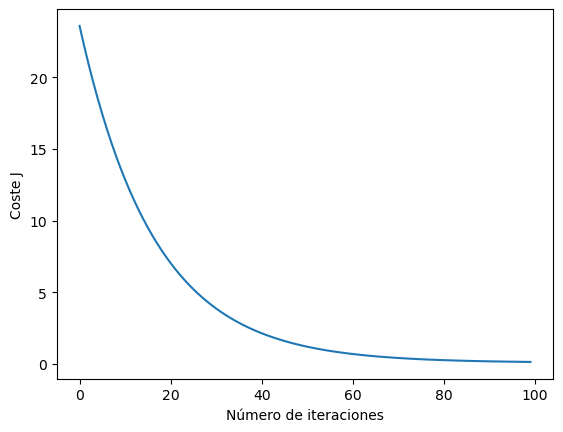

Valores Theta calculados por el descenso del gradiente: 
 [[6.73238426]
 [0.05912373]
 [0.0883419 ]
 [0.08226049]
 [0.0462853 ]] 



In [17]:
plt.plot(J_history['iteracion'], J_history['coste'])
plt.xlabel('Número de iteraciones')
plt.ylabel('Coste J')
plt.show()

print('Valores Theta calculados por el descenso del gradiente: \n', theta_gd, '\n')

#### Predecir valores- ejemplo

 Una vez que tenemos los coeficientes $\theta$, necesitamos verificar que el modelo funciona en la práctica. Este paso muestra cómo se utilizaría el modelo: toma datos nuevos, se normalizan usando los mismos parámetros con los que entrenamos y aplicamos la fórmula de predicción.

In [26]:
x_input = np.array([1,(10 - mu['depth']) / sigma['depth'],(5 - mu['cdi']) / sigma['cdi'],(4 - mu['mmi']) / sigma['mmi'],(300 - mu['sig']) / sigma['sig']], dtype=float)
magnitude = float(np.dot(x_input, theta_gd)[0])
print('Magnitud predicha:',magnitude)
print('Coste desc grad:\n\t',computeCostMulti(X_train_norm,y_train,theta_gd))

Magnitud predicha: 6.687410749067698
Coste desc grad:
	 0.13466267738873955


#### Ecuación normal

Definimos y usamos la función normalEqn

Es un método analítico exacto para encontrar el punto óptimo en un solo paso, sin iteraciones. Se usa para comparar y validar los resultados del Descenso del Gradiente.


In [27]:
# normalEqn Calcula la solución en forma cerrada de la regresión lineal
# normalEqn(X,y) calcula la solución en forma cerrada de la regresión lineal utilizando las ecuaciones normales.

def normalEqn(X, y):
    #theta = np.zeros(size(X, 2), 1)
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T,X)), X.T), y)
    # pinv es la pseudoinversa
    pinv = np.dot(np.linalg.inv((np.dot(X.T, X))), X.T)
    pinv2 = np.linalg.pinv(X)
    # inv es la inversa
    return theta

Vamos a usar los mismos valores de ejemplo que hemos utilizado en el apartado anterior

In [28]:

ones_train = np.ones((len(y_train), 1)) 
X_train_con_unos = X_train.copy()
X_train_con_unos['ones'] = ones_train
X_train_con_unos = X_train_con_unos[['ones','depth','cdi','mmi','sig']]


theta_normal = normalEqn(X_train_con_unos, y_train)
print('Theta computed from the normal equations: \n', theta_normal, "\n")

print("Coste ecuación normal:\n\t ", computeCostMulti(X_train_con_unos, y_train, theta_normal))

Theta computed from the normal equations: 
 [[6.23279204e+00]
 [7.82313205e-04]
 [3.85712349e-02]
 [7.68131218e-02]
 [6.29141177e-04]] 

Coste ecuación normal:
	  0.07796355686665714


#### definir métricas

Vamos a definir y utilizar los tres tipos de métricas.

El coste J del entrenamiento es un número abstracto difícil de interpretar.

MAE (Error Absoluto Medio) Nos dice, en unidades de magnitud, cuánto nos equivocamos en promedio 

MSE (Mean Squared Error) Se elige porque penaliza los errores grandes más que los pequeños 

MAPE (Error Porcentual) Nos dice el error relativo 

Usamos el conjunto de Test para simular cómo se comportaría el modelo en el mundo real con terremotos que nunca ha visto antes.

In [29]:
def calcular_mae(y_true, y_pred):
    #conversion a array por si vienen como listas o series
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Calcular la media de las diferencias absolutas
    return np.mean(np.abs(y_true - y_pred))

def calcular_mse(y_true, y_pred):
    #conversion a array por si vienen como listas o series
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Calcular la media de las diferencias al cuadrado
    return np.mean((y_true - y_pred)**2)

def calcular_mape(y_true, y_pred):
    #conversion a array por si vienen como listas o series
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # Crear máscara para evitar divisiones por cero
    mask = y_true != 0
    # Calcular la media de las diferencias porcentuales absolutas
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

#### evaluar descenso de gradiente con test

El objetivo final de cualquier modelo de Machine Learning es funcionar bien con datos que nunca ha visto.

Si evaluáramos solo con los datos de entrenamiento (train), el resultado podría ser engañoso si el modelo simplemente hubiera memorizado los datos. Evaluar con el conjunto de test nos da la medida real de la capacidad predictiva del modelo.

In [30]:
ones_test = np.ones((len(y_test), 1))
X_test_norm_con_unos = X_test_norm.copy()
X_test_norm_con_unos['ones'] = ones_test
X_test_norm_con_unos = X_test_norm_con_unos[['ones', 'depth', 'cdi','mmi','sig']]

y_pred_gd = np.dot(X_test_norm_con_unos, theta_gd)

print("--- Métricas Descenso Gradiente (en Test) ---")
print(f"MAE: {calcular_mae(y_test, y_pred_gd)}")
print(f"MSE: {calcular_mse(y_test, y_pred_gd)}")
print(f"MAPE: {calcular_mape(y_test, y_pred_gd)}%")

--- Métricas Descenso Gradiente (en Test) ---
MAE: 0.3597233810513618
MSE: 0.2196509492230351
MAPE: 4.930640739690198%


#### evaluar ecuacion normal con test

 Calculamos las mismas métricas usando los $\theta$ (theta) obtenidos por la Ecuación Normal sobre el conjunto de test. 

 La Ecuación Normal nos da la solución matemática óptima para este conjunto de datos. Al evaluarla con el mismo conjunto de test, establecemos un tope de rendimiento. Si el Descenso del Gradiente tiene un error mucho mayor que la Ecuación Normal, sabríamos  que al Gradiente le faltó entrenamiento (más iteraciones) o un mejor ajuste de parámetros ($\alpha$), ya que teóricamente deberían llegar al mismo resultado.

In [31]:

ones_test_raw = np.ones((len(y_test), 1))
X_test_con_unos = X_test.copy()
X_test_con_unos['ones'] = ones_test_raw
X_test_con_unos = X_test_con_unos[['ones','depth','cdi','mmi','sig']]

y_pred_normal = np.dot(X_test_con_unos, theta_normal)

# 3. Calcula y muestra métricas
print("\n--- Métricas Ecuación Normal (en Test) ---")
print(f"MAE: {calcular_mae(y_test, y_pred_normal)}")
print(f"MSE: {calcular_mse(y_test, y_pred_normal)}")
print(f"MAPE: {calcular_mape(y_test, y_pred_normal)}%")


--- Métricas Ecuación Normal (en Test) ---
MAE: 0.29066563677085533
MSE: 0.12937861534920866
MAPE: 4.118245819257203%


#### Comparación y Análisis de los resultados



Se evaluaron los dos métodos de Regresión Lineal (Descenso de Gradiente y Ecuación Normal) sobre el conjunto de prueba (20% de los datos), que el modelo nunca había visto.

##### Rendimiento

Descenso Gradiente | 0.3597233810513618 | 0.2196509492230351 | 4.930640739690198% |

Ecuación Normal | 0.29066563677085533 | 0.12937861534920866 | 4.118245819257203% |

---
##### Análisis de Resultados

Comparación: Se observa que los resultados del descenso gradiante son algo mas altos que los de la ecuación normal. Esto indica que el descenso de gradiente no convergió completamente al mínimo coste. El número de iteraciones no fue suficiente para alcanzar el mismo punto optimo que la ecuación normal. Por tanto, el modelo de la ecuación normal es objetivamente mejor.

Interpretación (Análisis en profundidad):
**MAE:** Un MAE de 0.29 indica que, en promedio, nuestras predicciones de magnitud se desvían 0.29 unidades del valor real.
**MAPE:** Un MAPE del 4.12% es un resultado sólido. Significa que el error promedio de predicción es solo un 4.12% del valor real de la magnitud.
**Causa del Error:** Aunque el MAPE es bajo, el error no es cero. Como se observó en el Análisis Inicial de Datos, la relación lineal no era perfecta. Las variables `depth` y `sig` mostraban una correlación débil o nula con la magnitud. La Regresión Lineal asume una relación lineal que no se cumple del todo en los datos, lo que explica el error residual.

---

##### Ventajas e Inconvenientes Observados

Descenso Gradiente (GD):
*Ventaja:* Escala mejor a conjuntos de datos con muchísimas características.
*Inconveniente:* Requiere normalización de características y un ajuste manual de parámetros (alpha y num_iters) para asegurar la convergencia

Ecuación Normal (E.N.):
*Ventaja:* Es una solución directa y exacta. No requiere normalización ni ajuste de parámetros.
*Inconveniente:* Es computacionalmente muy costosa si el número de características (N) es grande (ej. > 10,000).